# Pandas Practice: Bike Share Trip Data

This notebook gives you practice using Pandas on a messier, more realistic dataset. You'll work with February 2014 trip data from a bike share scheme — cleaning column names, exploring patterns, filtering, grouping, and creating visualisations. A good data scientist doesn't always invent solutions from scratch; knowing where to look and how to adapt existing code is a core skill. If you get stuck, [Sebastian Raschka's Pandas tips](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb) and the [Pandas documentation](https://pandas.pydata.org/docs/) are excellent references.

---

<center><img src="../images/nextbike_bike_rental_berlin.jpg" width="800"/></center>

In [100]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/bike_share_201402_trip_data.csv')
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


## Part 1 — Cleaning and Exploring

### Challenge 1: How many trips are in the dataset?

Find the number of observations (rows) in the DataFrame.

In [5]:
#df.shape[0]
len(df)

144015

### Challenge 2: Make the column names Pythonic

Rename all columns so they are:
- **Lowercase**
- Spaces replaced with `_`
- `#` replaced with `num`

Print the updated column names to verify.

In [113]:
df.columns = [col.replace(' ', '_') for col in df.columns]
df.columns = [col.replace('#', 'num') for col in df.columns]
df.columns = df.columns.str.lower()
df.columns

Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='str')

---

## Part 2 — Subscription Analysis

### Challenge 3: Subscription types

How many types of subscription are there? What are they?

In [13]:
df['subscription_type'].unique()

<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

### Challenge 4: Frequency of each subscription type

How many trips were made by each subscription type?

In [24]:
#df.groupby('subscription_type').count()
subscriptions = df['subscription_type'].value_counts()
subscriptions.reset_index()


,subscription_type,count
0,Subscriber,113647
1,Customer,30368


### Challenge 5: Visualise subscription frequency — pie chart

Plot the frequency of each subscription type as a pie chart.

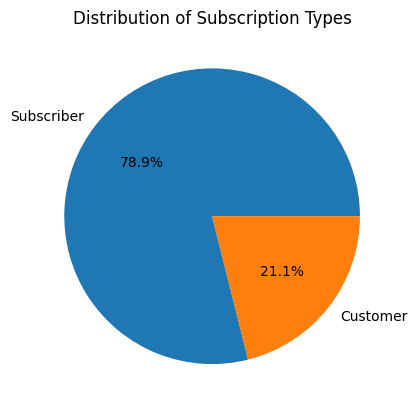

In [26]:
subscriptions.plot(kind='pie', autopct='%1.1f%%', title='Distribution of Subscription Types')
plt.show()

### Challenge 6: Visualise subscription frequency — bar chart

Plot the same data as a bar chart.

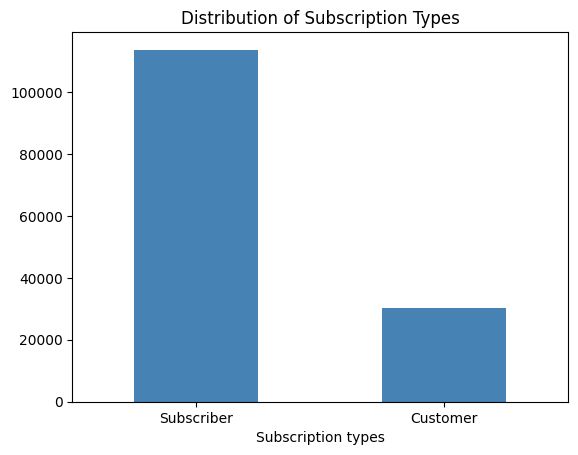

In [37]:
subscriptions.plot(kind='bar', title='Distribution of Subscription Types', color='steelblue', rot=0)

plt.xlabel('Subscription types')
plt.show()

---

## Part 3 — Station Analysis

### Challenge 7: Top 10 most popular start stations

Which 10 start stations appear most frequently in the data?

In [ ]:
df['start_station'].value_counts().head(10).reset_index()

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

### Challenge 8: 10 least popular end stations

Which 10 end stations appear least often?

In [44]:
df['end_station'].value_counts().tail(10).reset_index()

,end_station,count
0,Broadway St at Battery St,205
1,Redwood City Medical Center,178
2,Castro Street and El Camino Real,129
3,Redwood City Public Library,117
4,San Mateo County Center,106
5,Franklin at Maple,93
6,San Antonio Shopping Center,93
7,Broadway at Main,56
8,San Jose Government Center,23
9,Mezes Park,5


### Challenge 9: Cross-tabulation of start stations by subscription type

Create a table that shows the count of trips for each `start_station` segmented by `subscription_type`, including row and column totals (subtotals).

> Hint: look up `pd.crosstab()` in the documentation.

In [48]:
table = pd.crosstab(df['start_station'], df['subscription_type'], margins=True, margins_name='Total')
table

#df.columns

subscription_type,Customer,Subscriber,Total
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


---

## Part 4 — Trip Duration

### Challenge 10: Explore duration

What unit do you think the `duration` column uses? Find the shortest and longest trips. How many trips are as short as the minimum?

In [ ]:
# duration in minutes because the min is 60
df['duration'].describe()

min_duration = df['duration'].min()
max_duration = df['duration'].max()

print ("min_duration:", min_duration)
print ("max_duration:", max_duration)

min_tips_duration = (df['duration'] == min_duration).sum()
print ("number of min_tips_duration: ", min_tips_duration)

min_duration: 60
max_duration: 722236
number of min_tips_duration:  17


count    144015.000000
mean       1230.910141
std        6652.962329
min          60.000000
25%         349.000000
50%         531.000000
75%         797.000000
max      722236.000000
Name: duration, dtype: float64

### Challenge 11: Define and count "long" trips

Define what you consider a "long" trip (justify your threshold). How many trips meet that definition? What might explain the very long durations?

In [ ]:
# a long trip can be longer than 60000
#long_trips = (df['duration'] >= 60000).sum()
#print(long_trips)

threshold = df['duration'].quantile(0.95) # the last quartile gives a statistical better threshold for the used dataset
print ("threshold: ", threshold.round(2))

long_trips = (df['duration'] > threshold).sum()
print(long_trips, "trips meet the threshold")
#the very long durations may be due to different difficulties during the trip

#df.sort_values('duration', ascending=False).head(10)

threshold:  2479.6
7201 trips meet the threshold


,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
80510,111309,722236,11/30/2013 13:29,University and Emerson,35,12/8/2013 22:06,University and Emerson,35,247,Customer,94301
93400,129504,619322,12/18/2013 9:16,San Jose Diridon Caltrain Station,2,12/25/2013 13:18,SJSU 4th at San Carlos,12,653,Subscriber,94041
20535,32121,597517,9/23/2013 18:24,California Ave Caltrain Station,36,9/30/2013 16:23,Palo Alto Caltrain Station,34,168,Customer,95051
119830,166010,586356,1/25/2014 20:00,San Antonio Caltrain Station,29,2/1/2014 14:53,San Antonio Caltrain Station,29,693,Customer,94303
43549,62246,429384,10/17/2013 16:06,Davis at Jackson,42,10/22/2013 15:23,Powell Street BART,39,465,Customer,43113
24068,36617,329456,9/26/2013 20:51,Park at Olive,38,9/30/2013 16:22,Palo Alto Caltrain Station,34,162,Customer,94306
12725,21760,309479,9/14/2013 18:21,SJSU 4th at San Carlos,12,9/18/2013 8:19,SJSU - San Salvador at 9th,16,242,Customer,95112
108144,150269,303271,1/11/2014 20:16,Civic Center BART (7th at Market),72,1/15/2014 8:31,Civic Center BART (7th at Market),72,538,Customer,94110
100174,138946,296045,12/31/2013 9:43,Rengstorff Avenue / California Street,33,1/3/2014 19:57,Rengstorff Avenue / California Street,33,217,Customer,NaN
80086,110706,280439,11/29/2013 11:33,Post at Kearney,47,12/2/2013 17:27,Market at Sansome,77,593,Customer,33141


### Challenge 12: Plot the duration distribution

Create a histogram of the `duration` column. Does it give clear insights? If not, filter to a more meaningful range and re-plot.

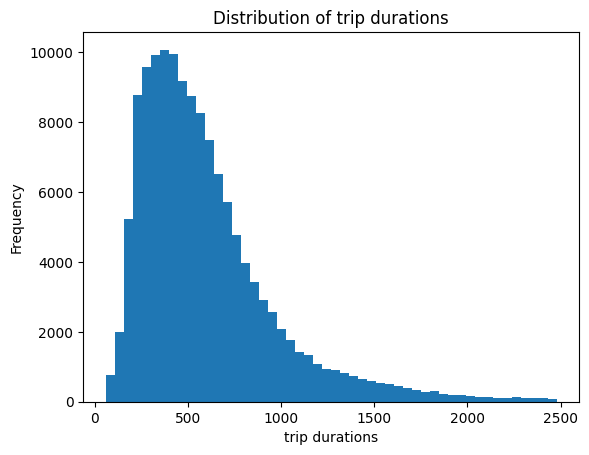

In [ ]:
# This is not very informative. It is dominated by outliers
df['duration'].plot(kind='hist', bins=50, title='Distribution of trip durations')

#quintile is used for clearer insights. It reveals actual behavior patter
df[df['duration'] <= threshold]['duration'].plot(kind='hist', bins=50, title='Distribution of trip durations') 

plt.xlabel('Trip durations')
plt.show()

---

## Part 5 — Data Cleaning (Advanced)

### Challenge 13: Normalise station names

The product team wants all station names to be lowercase with underscores as separators.

Example: `South Van Ness at Market` → `south_van_ness_at_market`

Apply this transformation to both the `start_station` and `end_station` columns.

> **Do NOT use a for loop.** Use a vectorised Pandas string method instead — it will be much faster.

In [114]:
df['start_station'] = (df['start_station'].str.strip().str.lower().str.replace(r'\s+', '_', regex=True))
df['end_station'] = (df['end_station'].str.strip().str.lower().str.replace(r'\s+', '_', regex=True))

df[['start_station', 'end_station']].head()

,start_station,end_station
0,south_van_ness_at_market,south_van_ness_at_market
1,san_jose_city_hall,san_jose_city_hall
2,mountain_view_city_hall,mountain_view_city_hall
3,san_jose_city_hall,san_jose_city_hall
4,south_van_ness_at_market,market_at_10th


### Challenge 14: Open-ended exploration

Set a 15-minute timer. Use that time to explore the data guided by your own curiosity or hypotheses. What patterns can you find?

> Time-boxing is a useful technique when exploring new data — it prevents you from falling into rabbit holes and forces you to prioritise the most interesting questions.

In [ ]:
#There are more subscribers (78%) than customer (21%) types